<a href="https://colab.research.google.com/github/Jyothik178/Machine-Learning-Skill/blob/main/2420080039_week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score

import time
import string

# ============================
# LOAD DATASETS
# ============================
print("Loading datasets...")

iris = load_iris()

df_sms = pd.read_csv(
    'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv',
    sep='\t',
    names=['label', 'message']
)

# ============================
# PART A: K-NN IMPLEMENTATION
# ============================
print("\n" + "=" * 50)
print("PART A: K-NN Implementation")
print("=" * 50)

# Prepare Iris data
X_iris = iris.data[:, :2]   # Use first two features
y_iris = iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris,
    y_iris,
    test_size=0.3,
    random_state=42
)

# ============================
# EVALUATE K-NN WITH DIFFERENT k AND METRICS
# ============================
k_values = [1, 3, 5, 7, 9]
results_knn = []

for k in k_values:
    for metric in ['euclidean', 'manhattan']:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )
        knn.fit(X_train_i, y_train_i)

        acc = accuracy_score(
            y_test_i,
            knn.predict(X_test_i)
        )

        results_knn.append([k, metric, acc])
        print(f"K={k}, {metric}: Accuracy={acc:.3f}")


Loading datasets...

PART A: K-NN Implementation
K=1, euclidean: Accuracy=0.711
K=1, manhattan: Accuracy=0.711
K=3, euclidean: Accuracy=0.756
K=3, manhattan: Accuracy=0.756
K=5, euclidean: Accuracy=0.778
K=5, manhattan: Accuracy=0.800
K=7, euclidean: Accuracy=0.800
K=7, manhattan: Accuracy=0.778
K=9, euclidean: Accuracy=0.800
K=9, manhattan: Accuracy=0.778


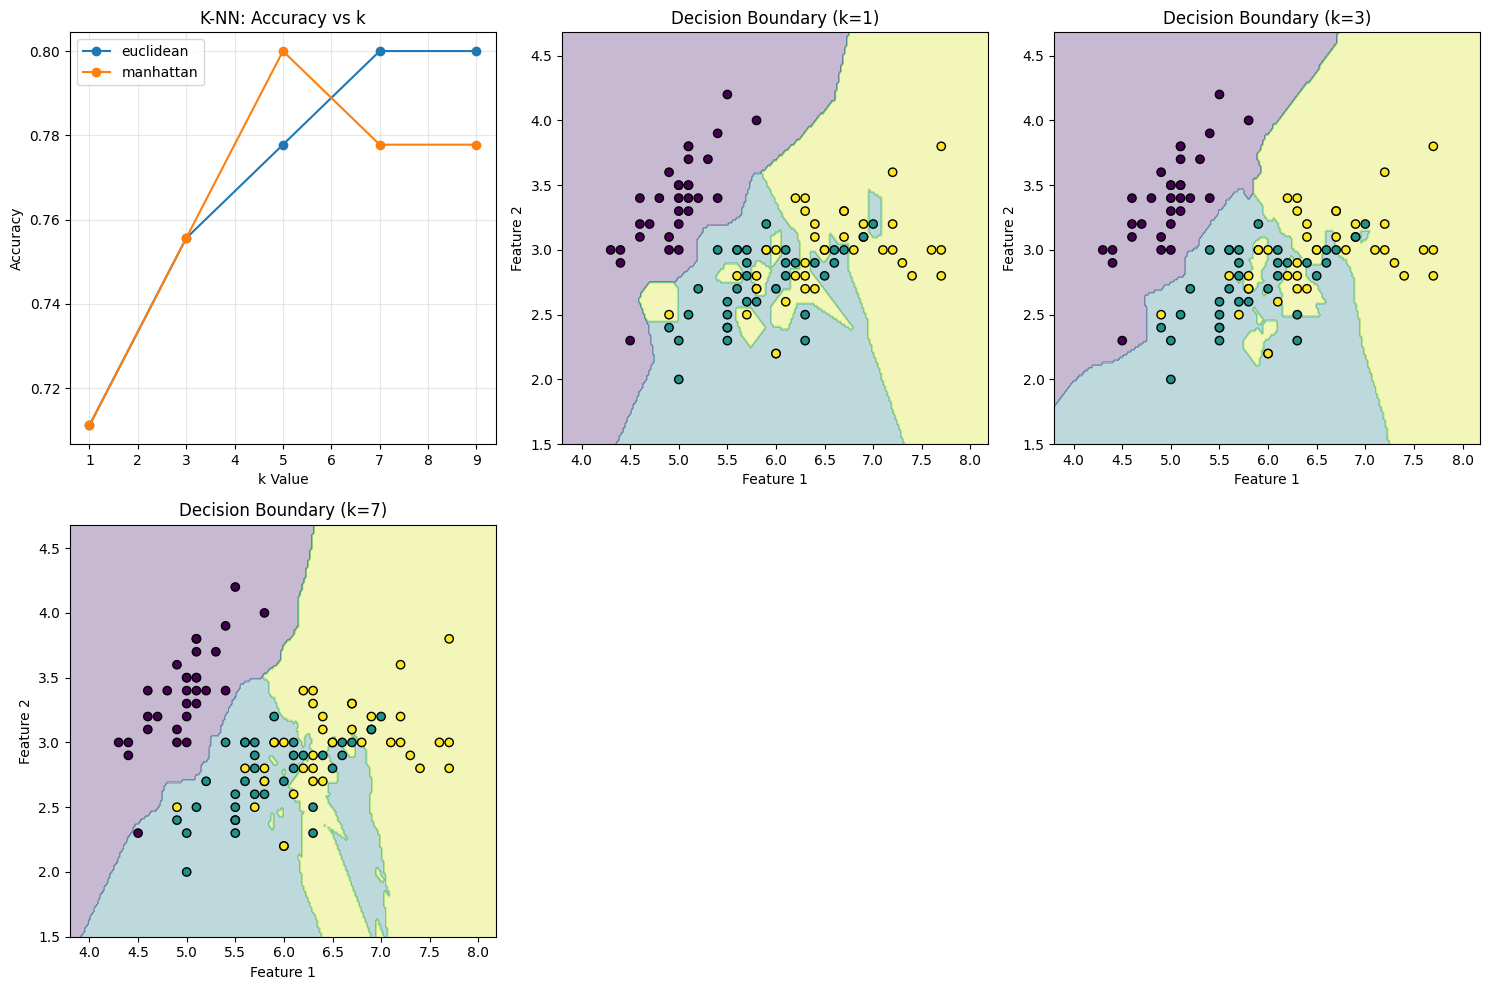

In [ ]:
# ============================
# PLOT ACCURACY VS k
# ============================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
df_knn = pd.DataFrame(results_knn, columns=['k', 'metric', 'accuracy'])

for metric in ['euclidean', 'manhattan']:
    data = df_knn[df_knn['metric'] == metric]
    plt.plot(data['k'], data['accuracy'], marker='o', label=metric)

plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('K-NN: Accuracy vs k')
plt.legend()
plt.grid(True, alpha=0.3)

# ============================
# VISUALIZE DECISION BOUNDARIES
# ============================
for idx, k in enumerate([1, 3, 7], 2):
    plt.subplot(2, 3, idx)

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_i, y_train_i)

    # Create mesh
    x_min, x_max = X_train_i[:, 0].min() - 0.5, X_train_i[:, 0].max() + 0.5
    y_min, y_max = X_train_i[:, 1].min() - 0.5, X_train_i[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict and plot
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(
        X_train_i[:, 0],
        X_train_i[:, 1],
        c=y_train_i,
        edgecolor='k'
    )

    plt.title(f'Decision Boundary (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()


In [ ]:
# ============================
# PART B: NAIVE BAYES IMPLEMENTATION
# ============================
print("\n" + "=" * 50)
print("PART B: Naive Bayes Implementation")
print("=" * 50)

# ============================
# PREPROCESS SMS DATA
# ============================
df_sms['label'] = df_sms['label'].map({'ham': 0, 'spam': 1})

df_sms['processed'] = (
    df_sms['message']
    .str.lower()
    .str.replace(f'[{string.punctuation}]', '', regex=True)
)

# ============================
# TRAIN–TEST SPLIT
# ============================
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df_sms['processed'],
    df_sms['label'],
    test_size=0.3,
    random_state=42
)

# ============================
# TEXT VECTORIZATION
# ============================
vectorizer = CountVectorizer(max_features=1000)

X_train_vec = vectorizer.fit_transform(X_train_s)
X_test_vec = vectorizer.transform(X_test_s)

# ============================
# NUMERICAL FEATURES (FOR GAUSSIAN NB)
# ============================
X_train_num = np.array([
    [len(msg), len(msg.split())] for msg in X_train_s
])

X_test_num = np.array([
    [len(msg), len(msg.split())] for msg in X_test_s
])

# ============================
# MULTINOMIAL NAIVE BAYES
# ============================
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train_s)

y_pred_mnb = mnb.predict(X_test_vec)
acc_mnb = accuracy_score(y_test_s, y_pred_mnb)

print(f"Multinomial NB Accuracy: {acc_mnb:.3f}")

# ============================
# GAUSSIAN NAIVE BAYES
# ============================
gnb = GaussianNB()
gnb.fit(X_train_num, y_train_s)

y_pred_gnb = gnb.predict(X_test_num)
acc_gnb = accuracy_score(y_test_s, y_pred_gnb)

print(f"Gaussian NB Accuracy: {acc_gnb:.3f}")



PART B: Naive Bayes Implementation
Multinomial NB Accuracy: 0.984
Gaussian NB Accuracy: 0.865



Probability comparison (first 3 samples):
Sample 1: MNB[ham=1.000, spam=0.000] | GNB[ham=0.478, spam=0.522]
Sample 2: MNB[ham=1.000, spam=0.000] | GNB[ham=0.497, spam=0.503]
Sample 3: MNB[ham=1.000, spam=0.000] | GNB[ham=0.671, spam=0.329]

PART C: Algorithm Comparison


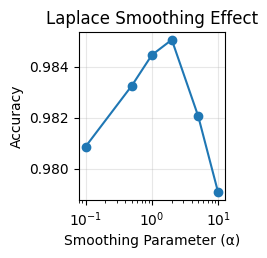

In [ ]:
# ============================
# LAPLACE SMOOTHING EFFECT
# ============================
plt.subplot(2, 3, 5)

alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
accuracies = []

for alpha in alphas:
    mnb_smooth = MultinomialNB(alpha=alpha)
    mnb_smooth.fit(X_train_vec, y_train_s)
    y_pred = mnb_smooth.predict(X_test_vec)
    acc = accuracy_score(y_test_s, y_pred)
    accuracies.append(acc)

plt.plot(alphas, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('Smoothing Parameter (α)')
plt.ylabel('Accuracy')
plt.title('Laplace Smoothing Effect')
plt.grid(True, alpha=0.3)

# ============================
# COMPARE PROBABILITIES
# ============================
print("\nProbability comparison (first 3 samples):")

probs_mnb = mnb.predict_proba(X_test_vec)[:3]
probs_gnb = gnb.predict_proba(X_test_num)[:3]

for i in range(3):
    print(
        f"Sample {i+1}: "
        f"MNB[ham={probs_mnb[i][0]:.3f}, spam={probs_mnb[i][1]:.3f}] | "
        f"GNB[ham={probs_gnb[i][0]:.3f}, spam={probs_gnb[i][1]:.3f}]"
    )

# ============================
# PART C: ALGORITHM COMPARISON
# ============================
print("\n" + "=" * 50)
print("PART C: Algorithm Comparison")
print("=" * 50)

def evaluate_algo(model, X_train, X_test, y_train, y_test, name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    return {
        'Algorithm': name,
        'Accuracy': f"{acc:.3f}",
        'Precision': f"{prec:.3f}",
        'Recall': f"{rec:.3f}",
        'Train Time (ms)': f"{train_time * 1000:.2f}",
        'Pred Time (ms)': f"{pred_time * 1000:.2f}"
    }



Algorithm Comparison Table:
           Algorithm Accuracy Precision Recall Train Time (ms) Pred Time (ms)
         K-NN (Iris)    0.778     0.778  0.778            1.84           7.04
  Gaussian NB (Iris)    0.822     0.834  0.822            1.94           0.50
          K-NN (SMS)    0.925     0.931  0.925            1.63         881.35
Multinomial NB (SMS)    0.984     0.985  0.984            5.02           0.94
   Gaussian NB (SMS)    0.865     0.897  0.865            7.06           0.72


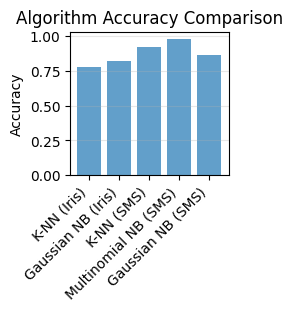

In [ ]:
# ============================
# COMPARE ON IRIS DATASET
# ============================
results = []

results.append(
    evaluate_algo(
        KNeighborsClassifier(n_neighbors=5),
        X_train_i,
        X_test_i,
        y_train_i,
        y_test_i,
        "K-NN (Iris)"
    )
)

results.append(
    evaluate_algo(
        GaussianNB(),
        X_train_i,
        X_test_i,
        y_train_i,
        y_test_i,
        "Gaussian NB (Iris)"
    )
)

# ============================
# COMPARE ON SMS DATASET
# ============================
results.append(
    evaluate_algo(
        KNeighborsClassifier(n_neighbors=5),
        X_train_vec.toarray(),
        X_test_vec.toarray(),
        y_train_s,
        y_test_s,
        "K-NN (SMS)"
    )
)

results.append(
    evaluate_algo(
        MultinomialNB(),
        X_train_vec,
        X_test_vec,
        y_train_s,
        y_test_s,
        "Multinomial NB (SMS)"
    )
)

results.append(
    evaluate_algo(
        GaussianNB(),
        X_train_num,
        X_test_num,
        y_train_s,
        y_test_s,
        "Gaussian NB (SMS)"
    )
)

# ============================
# DISPLAY COMPARISON TABLE
# ============================
df_comparison = pd.DataFrame(results)

print("\nAlgorithm Comparison Table:")
print(df_comparison.to_string(index=False))

# ============================
# VISUALIZATION OF COMPARISON
# ============================
plt.subplot(2, 3, 6)

x_pos = np.arange(len(results))
accuracies = [float(r['Accuracy']) for r in results]

plt.bar(x_pos, accuracies, alpha=0.7)
plt.xticks(
    x_pos,
    [r['Algorithm'] for r in results],
    rotation=45,
    ha='right'
)

plt.ylabel('Accuracy')
plt.title('Algorithm Accuracy Comparison')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
